# Intelligent Chatbot with Yoruba/English Language Understanding

**Machine learning pipeline: Intent Classification with TF-IDF + Logistic Regression**

This notebook builds the machine learning component of a text-based chatbot that
understands a user's intent and replies in **English**, **Yoruba**, or **Mixed**
Yoruba-English, depending on the language the user typed in.

**Pipeline:** user text → cleaning → preprocessing → TF-IDF → Logistic Regression →
predicted intent → language identification → response selection → chatbot reply.

The dataset used is **RAPH dataset** (converted from the source Yoruba-English
sentence pairs downloaded for this project), which seeds the raw language data in
Stage 1-2. The actual intent-labelled training data (150 intents) is built
programmatically in Stage 3-4 using sentence templates and keyword patterns, since
the source corpus has no intent labels of its own.


## Stage 1: Raw Data Acquisition

Load the existing Yoruba-English source dataset (**RAPH dataset**) and inspect its structure.

In [1]:
# Step 1: Load the raw Yoruba-English source dataset (RAPH dataset)
import pandas as pd

df = pd.read_csv("../data/RAPH dataset.csv")
df

,eng,yor
0,"We do not guarantee the accuracy , completenes...",A kò lè fọwọ́ sọ̀ yà pé ohun tá a bá kà lórí Í...
1,The Unclean One Will Not Pass Over It,Aláìmọ́ Kì Yóò Gbà Á Kọjá
2,"The person who proudly proclaims ' Oh , I list...","Bí ẹnì kan bá ń fọ́ nnu pé , ' Ní tèmi o , mo ..."
3,"Welcome Home , Son !",Káàbọ̀ Ọmọ Mi !
4,I HAVE often had the unreasoning fear that I w...,MO SÁBÀ máa ń ní ìbẹ̀ rù tí kò tọ́ pé mo máa ṣ...
...,...,...
411403,▪ Pornography demeans both those who produce i...,▪ Àwòrán oníhòòhò ń tàbùkù sáwọn tó ń ṣe é àtà...
411404,""" Sometimes because of my hectic schedule , pr...","▪ Ìṣòro : ÀÌKA NǸ KAN SÍ . "" Nígbà míì , torí ..."
411405,""" I lose my concentration , and my mind seems ...","▪ Ìṣòro : ÌPÍNYÀ ỌKÀN . "" Mi kì í pọkàn pọ̀ bí..."
411406,"● "" If , then , you are bringing your gift to ...","● "" Nígbà náà , bí ìwọ bá ń mú ẹ̀ bùn rẹ bọ̀ n..."


In [2]:
# Step 1: Inspect the structure of the source dataset
df.info()
print("\nColumn names:", df.columns.tolist())
print("Number of sentence pairs:", len(df))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411408 entries, 0 to 411407
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   eng     411408 non-null  object
 1   yor     411408 non-null  object
dtypes: object(2)
memory usage: 6.3+ MB

Column names: ['eng', 'yor']
Number of sentence pairs: 411408


## Stage 2: Source Data Preparation

The source dataset only has parallel `eng`/`yor` sentence pairs — it has **no
intent labels**. Here we reshape the **complete 411,408-row dataset** into the
unified `text` / `language` structure the chatbot needs, and demonstrate
building Yoruba-English **mixed** sentences programmatically from suitable
short sentence pairs. The actual 150-intent chatbot training data is built
separately in Stage 3-4; Stage 4 also mines real sentences from this same full
corpus for a set of topic intents.

In [3]:
# Step 2: Create separate text/language records for English and Yoruba,
# using the complete source dataset (all 411,408 sentence pairs)
english_records = pd.DataFrame({
    "text": df["eng"],
    "language": "English",
})
yoruba_records = pd.DataFrame({
    "text": df["yor"],
    "language": "Yoruba",
})
source_df = pd.concat([english_records, yoruba_records], ignore_index=True)
source_df.shape

(822816, 2)

In [4]:
# Step 2: Inspect the reshaped source dataframe
source_df

,text,language
0,"We do not guarantee the accuracy , completenes...",English
1,The Unclean One Will Not Pass Over It,English
2,"The person who proudly proclaims ' Oh , I list...",English
3,"Welcome Home , Son !",English
4,I HAVE often had the unreasoning fear that I w...,English
...,...,...
822811,▪ Àwòrán oníhòòhò ń tàbùkù sáwọn tó ń ṣe é àtà...,Yoruba
822812,"▪ Ìṣòro : ÀÌKA NǸ KAN SÍ . "" Nígbà míì , torí ...",Yoruba
822813,"▪ Ìṣòro : ÌPÍNYÀ ỌKÀN . "" Mi kì í pọkàn pọ̀ bí...",Yoruba
822814,"● "" Nígbà náà , bí ìwọ bá ń mú ẹ̀ bùn rẹ bọ̀ n...",Yoruba


In [5]:
# Step 2: Programmatically build Yoruba-English MIXED examples
# by joining a short English clause with a short Yoruba clause,
# using the complete source dataset.
import random

random.seed(1)
short_pairs = df[
    (df["eng"].str.len() < 40) & (df["yor"].str.len() < 40)
].reset_index(drop=True)

eng_clauses = short_pairs["eng"].tolist()
yor_clauses = short_pairs["yor"].tolist()

mixed_examples = []
for i in range(min(20, len(eng_clauses))):
    eng_part = eng_clauses[i]
    yor_part = yor_clauses[(i + 1) % len(yor_clauses)]
    mixed_examples.append(f"{eng_part}, {yor_part}")

mixed_source_df = pd.DataFrame({"text": mixed_examples, "language": "Mixed"})
mixed_source_df

,text,language
0,"The Unclean One Will Not Pass Over It, Káàbọ̀ ...",Mixed
1,"Welcome Home , Son !, Mi ò kúnjú ìwọ̀ n tó .",Mixed
2,"I am not good enough ., Àwọn Ará Wa Dúró Tì Wá...",Mixed
3,"Our Brothers Were There, Èyí Túmọ̀ Sí Ìyè Àìní...",Mixed
4,"This Means Everlasting Life, Ẹ Máa Sìnrú fún J...",Mixed
5,"Slave for Jehovah, ( Dá 9 : 24 ) , 5 / 15",Mixed
6,"Feel Misunderstood ?, ( Fi wé Aísáyà 32 : 1 , ...",Mixed
7,"( Compare Isaiah 32 : 1 , 2 . ), ( Ka 1 Kọ́ rí...",Mixed
8,"( Read 1 Corinthians 7 : 32 - 35 . ), ( Ka Aís...",Mixed
9,"( Read Isaiah 1 : 18 . ), ( Ka Hébérù 3 : 12 . )",Mixed


## Stage 3: Intent Creation

We define the **150 chatbot intents** required for this project. For each intent
we write real, meaningful example sentences in English and Yoruba (with proper
diacritics), plus a matching English response and Yoruba response. Text is
**never** randomly assigned to an intent — every example genuinely expresses that
intent's meaning.

To keep the 150 intents organised and avoid meaningless duplication, we use two
strategies:

1. **Bespoke intents** (general conversation, chatbot-identity questions, and
   social/personal support) get hand-written example sentences, since each of
   these needs genuinely distinct phrasing.
2. **Templated intents** (the "asking for X" / "request X" family, and the
   "tell me about topic Y" family) share a sentence-template structure and a
   per-intent keyword ("thing" or "topic"), which is exactly the kind of
   keyword-pattern / template-based generation this project calls for.

In [6]:
# Step 3.1: General Conversation intents (1-20) - bespoke, hand-written examples
BESPOKE = {}

BESPOKE['greeting'] = dict(
    category='General Conversation', description='User greets the chatbot',
    en=["Hello", "Hi there", "Hey", "Hello there", "Hi, good to meet you",
        "Hi, is anyone there", "Hello, how's it going", "Hey there, chatbot",
        "Good day", "Hiya"],
    yo=["Ẹ n lẹ́", "Bawo", "Ẹ káàsán", "Pẹ̀lẹ́ o", "Ẹ n lẹ́ o", "Báwo ni",
        "Ẹ ku ọjọ́ o", "Bawo ni o ṣe wa", "Ẹ n lẹ, olùrànlọ́wọ́", "Àlàáfíà ni"],
    mixed=["Hello, ẹ n lẹ́", "Hi, báwo ni", "Hey chatbot, bawo ni o ṣe wa"],
    resp_en="Hello! How can I help you?",
    resp_yo="Ẹ káàárọ̀! Báwo ni mo ṣe lè ràn ẹ́ lọ́wọ́?",
    resp_mixed="Hello! Báwo ni mo ṣe lè ràn ẹ́ lọ́wọ́?",
)
BESPOKE['good_morning'] = dict(
    category='General Conversation', description='User says good morning',
    en=["Good morning", "Good morning to you", "Morning", "Good morning, chatbot",
        "Good morning, hope you slept well", "A very good morning to you",
        "Morning, how are you today", "Good morning everyone"],
    yo=["Ẹ káàárọ̀", "Ẹ káàárọ̀ o", "Káàárọ̀", "Ẹ káàárọ̀ sí ẹ", "Ẹ káàárọ̀, olùrànlọ́wọ́",
        "Ẹ káàárọ̀, báwo ni oorun", "Ẹ káàárọ̀ o, ṣé dáadáa ni"],
    mixed=["Good morning, ẹ káàárọ̀ o", "Morning, ẹ káàárọ̀"],
    resp_en="Good morning! I hope you have a wonderful day.",
    resp_yo="Ẹ káàárọ̀ o! Mo fẹ́ kí o ní ọjọ́ tó dára.",
    resp_mixed="Good morning! Mo fẹ́ kí o ní ọjọ́ tó dára.",
)
BESPOKE['good_afternoon'] = dict(
    category='General Conversation', description='User says good afternoon',
    en=["Good afternoon", "Good afternoon to you", "Afternoon", "Good afternoon, chatbot",
        "Good afternoon, how is your day going", "A pleasant afternoon to you"],
    yo=["Ẹ káàsán", "Ẹ káàsán o", "Káàsán", "Ẹ káàsán sí ẹ", "Ẹ káàsán, báwo ni ọjọ́ n lọ",
        "Ẹ káàsán o, olùrànlọ́wọ́"],
    mixed=["Good afternoon, ẹ káàsán o"],
    resp_en="Good afternoon! How is your day going so far?",
    resp_yo="Ẹ káàsán o! Báwo ni ọjọ́ rẹ ti n lọ?",
    resp_mixed="Good afternoon! Báwo ni ọjọ́ rẹ ti n lọ?",
)
BESPOKE['good_evening'] = dict(
    category='General Conversation', description='User says good evening',
    en=["Good evening", "Good evening to you", "Evening", "Good evening, chatbot",
        "Good evening, how was your day", "A lovely evening to you"],
    yo=["Ẹ kúùrọ̀lẹ́", "Ẹ kúùrọ̀lẹ́ o", "Kúùrọ̀lẹ́", "Ẹ kúùrọ̀lẹ́ sí ẹ", "Ẹ kúùrọ̀lẹ́, báwo ni ọjọ́ rẹ"],
    mixed=["Good evening, ẹ kúùrọ̀lẹ́ o"],
    resp_en="Good evening! I hope you had a good day.",
    resp_yo="Ẹ kúùrọ̀lẹ́ o! Mo fẹ́ ki ọjọ́ rẹ ti dára.",
    resp_mixed="Good evening! Mo fẹ́ ki ọjọ́ rẹ ti dára.",
)
BESPOKE['good_night'] = dict(
    category='General Conversation', description='User says good night',
    en=["Good night", "Good night, chatbot", "Goodnight, sleep well", "Good night to you",
        "Have a good night", "Night night"],
    yo=["Ẹ kúùrọ̀lẹ́ o, o dàbọ̀", "Ẹ sùn ẹrun", "Oru rẹ ó dára", "Ẹ jí re, o dàbọ̀ lálẹ́",
        "Kú alẹ́", "Kú alẹ́ o, sùn dáadáa"],
    mixed=["Good night, ẹ sùn ẹrun"],
    resp_en="Good night! Sleep well and take care.",
    resp_yo="Kú alẹ́ o! Ẹ sùn dáadáa, ẹ ṣọ́ra.",
    resp_mixed="Good night! Ẹ sùn dáadáa, ẹ ṣọ́ra.",
)
BESPOKE['goodbye'] = dict(
    category='General Conversation', description='User says goodbye',
    en=["Goodbye", "Bye", "Bye bye", "See you later", "I have to go now, bye",
        "Goodbye for now", "Bye, talk soon", "See you", "I'm leaving now, goodbye"],
    yo=["Ó dàbọ̀", "Ó dàbọ̀ o", "Mo n lọ o", "A ó pàdé", "Mo fẹ́ lọ báyìí, ó dàbọ̀",
        "Ó dàbọ̀ fún báyìí", "Ẹ ku ìrìn", "A ó tún pàdé"],
    mixed=["Goodbye, ó dàbọ̀ o", "Bye, a ó pàdé"],
    resp_en="Goodbye! Feel free to come back anytime.",
    resp_yo="Ó dàbọ̀ o! Ẹ padà wá nígbàkigbà tí ẹ bá fẹ́.",
    resp_mixed="Goodbye! Ẹ padà wá nígbàkigbà tí ẹ bá fẹ́.",
)
BESPOKE['farewell'] = dict(
    category='General Conversation', description='User bids a warm farewell',
    en=["Take care", "Take care of yourself", "Farewell", "Wishing you well, farewell",
        "Stay safe, goodbye", "Have a safe trip, farewell"],
    yo=["Ẹ ṣọ́ra", "Ẹ máa ṣọ́ ara yín", "Ó dàbọ̀, ẹ ṣọ́ra", "Ẹ jẹ́ kí Ọlọ́run ṣọ́ ọ",
        "Ẹ ṣọ́ra o, a ó pàdé"],
    mixed=["Take care, ẹ ṣọ́ra o"],
    resp_en="Take care! It was nice talking with you.",
    resp_yo="Ẹ ṣọ́ra o! Inú mi dùn láti bá ọ sọ̀rọ̀.",
    resp_mixed="Take care! Inú mi dùn láti bá ọ sọ̀rọ̀.",
)
BESPOKE['how_are_you'] = dict(
    category='General Conversation', description='User asks how the bot is doing',
    en=["How are you", "How are you doing", "How's it going", "How are you today",
        "Are you okay", "How have you been", "How is everything with you"],
    yo=["Báwo ni", "Báwo ni o ṣe wà", "Ṣé dáadáa ni", "Báwo ni ara rẹ", "Ǹjẹ́ àlàáfíà ni",
        "Báwo ni nǹkan", "Ṣé o wà dáadáa"],
    mixed=["How are you, ṣé dáadáa ni"],
    resp_en="I'm doing great, thank you for asking! How about you?",
    resp_yo="Àlàáfíà ni, ẹ ṣé fún bíbéèrè! Ẹ nkọ́?",
    resp_mixed="I'm doing great! Ẹ nkọ́, ṣé àlàáfíà ni?",
)
BESPOKE['thanks'] = dict(
    category='General Conversation', description='User expresses thanks',
    en=["Thank you", "Thanks a lot", "Thank you so much", "I appreciate it", "Thanks",
        "Thank you for your help", "Much appreciated", "Thanks a bunch"],
    yo=["Ẹ ṣé", "Ẹ ṣé púpọ̀", "Mo dúpẹ́", "Mo dúpẹ́ lọ́wọ́ rẹ", "Ẹ ṣé o", "Ó ṣé", "Mo dúpẹ́ gan an"],
    mixed=["Thank you, ẹ ṣé púpọ̀"],
    resp_en="You're welcome! I'm happy I could help.",
    resp_yo="Kò tọ́pá! Inú mi dùn pé mo lè ràn ẹ́ lọ́wọ́.",
    resp_mixed="You're welcome! Inú mi dùn pé mo lè ràn ẹ́ lọ́wọ́.",
)
BESPOKE['apology'] = dict(
    category='General Conversation', description='User apologises for something',
    en=["I'm sorry", "Sorry about that", "My apologies", "I apologize", "Sorry, my mistake",
        "I'm sorry for the confusion", "Sorry, I didn't mean that"],
    yo=["Ẹ má bínú", "Má bínú", "Ẹ má bínú sí mi", "Àṣìṣe mi ni, ẹ má bínú",
        "Ẹ dárí ji mi", "Ẹ má bínú, kò yẹ kí n ṣe bẹ́ẹ̀"],
    mixed=["I'm sorry, ẹ má bínú"],
    resp_en="No worries at all, it's completely fine.",
    resp_yo="Kò sí ìṣòro, ohun gbogbo dáa.",
    resp_mixed="No worries at all, ohun gbogbo dáa.",
)
BESPOKE['welcome'] = dict(
    category='General Conversation', description="Bot or user acknowledges a you're-welcome style exchange",
    en=["You're welcome", "No problem", "Anytime", "It's my pleasure", "Not a problem at all",
        "Glad to help"],
    yo=["Kò tọ́pá", "Kò sí ìṣòro", "Nígbàkigbà", "Inú mi dùn láti ràn ẹ́ lọ́wọ́", "Kò sí wàhálà"],
    mixed=["You're welcome, kò tọ́pá"],
    resp_en="Glad to be of help whenever you need me.",
    resp_yo="Inú mi máa n dùn láti ràn ẹ lọ́wọ́ nígbàkigbà.",
    resp_mixed="Glad to help! Nígbàkigbà tí o bá nílò mi, mo wà.",
)
BESPOKE['agreement'] = dict(
    category='General Conversation', description='User agrees with something',
    en=["Yes, that's correct", "I agree", "That's right", "Sure, that works for me", "Okay, agreed",
        "Yes, exactly", "That sounds good to me"],
    yo=["Bẹ́ẹ̀ni, ó tọ́", "Mo gbà", "Ó tọ́", "Ó dáa, ó bá mi mu", "Bẹ́ẹ̀ni, ó dáa", "Bẹ́ẹ̀ni gan an"],
    mixed=["Yes, ó tọ́ o", "I agree, ó dáa"],
    resp_en="Great, I'm glad we're on the same page.",
    resp_yo="Ó dáa, inú mi dùn pé a fohùn ṣọ̀kan.",
    resp_mixed="Great! A fohùn ṣọ̀kan gan an.",
)
BESPOKE['disagreement'] = dict(
    category='General Conversation', description='User disagrees with something',
    en=["I disagree", "No, that's not right", "I don't think so", "That's not correct",
        "I don't agree with that", "No, I don't think that's true"],
    yo=["Mi ò gbà", "Rárá, kò tọ́", "N kò rò bẹ́ẹ̀", "Kò tọ́", "Mi ò fohùn ṣọ̀kan pẹ̀lú ìyẹn"],
    mixed=["I disagree, kò tọ́"],
    resp_en="That's alright, thanks for sharing your view.",
    resp_yo="Kò sí ìṣòro, ẹ ṣé fún pínpín èrò yín.",
    resp_mixed="That's alright! Ẹ ṣé fún pínpín èrò yín.",
)
BESPOKE['confirmation'] = dict(
    category='General Conversation', description='User confirms an action or statement',
    en=["Yes, please confirm", "That's confirmed", "Confirmed", "Yes, go ahead", "Yes, proceed with that",
        "Correct, please continue"],
    yo=["Bẹ́ẹ̀ni, ẹ jẹ́rìí sí i", "Ó dájú", "Bẹ́ẹ̀ni, ẹ tẹ̀síwájú", "Ó tọ́, ẹ máa lọ"],
    mixed=["Yes, ó dájú"],
    resp_en="Confirmed. I'll proceed with that right away.",
    resp_yo="Ó dájú. Màá tẹ̀síwájú pẹ̀lú rẹ̀ báyìí.",
    resp_mixed="Confirmed! Màá tẹ̀síwájú báyìí.",
)
BESPOKE['denial'] = dict(
    category='General Conversation', description='User denies something',
    en=["No, that's not true", "I deny that", "That never happened", "No, I did not say that",
        "That's false", "No, not at all"],
    yo=["Rárá, kò rí bẹ́ẹ̀", "N kò gbà á", "Kò rí bẹ́ẹ̀ rárá", "Rárá, mi ò sọ bẹ́ẹ̀"],
    mixed=["No, kò rí bẹ́ẹ̀"],
    resp_en="Understood, thank you for clarifying that.",
    resp_yo="Mo yé mi, ẹ ṣé fún ṣíṣe àlàyé náà.",
    resp_mixed="Understood! Ẹ ṣé fún ṣíṣe àlàyé náà.",
)
BESPOKE['casual_conversation'] = dict(
    category='General Conversation', description='Small talk / casual chit-chat',
    en=["What's up", "How's your day been", "Just checking in", "So what's new", "What's going on",
        "How have things been lately"],
    yo=["Kín le", "Báwo ni ọjọ́ rẹ", "Mo kàn wo bí nǹkan ṣe rí ni", "Kí ló n ṣẹlẹ̀", "Kín ló wa"],
    mixed=["What's up, kín le"],
    resp_en="Not much, just here ready to chat with you!",
    resp_yo="Kò sí púpọ̀, mo wà níbí ṣetán láti bá ọ sọ̀rọ̀!",
    resp_mixed="Not much, mo wà níbí ṣetán láti bá ọ sọ̀rọ̀!",
)
BESPOKE['start_conversation'] = dict(
    category='General Conversation', description='User wants to start chatting',
    en=["Can we talk", "I want to start a conversation", "Let's chat", "Can we chat for a bit",
        "I'd like to talk to you"],
    yo=["Ǹjẹ́ a lè sọ̀rọ̀", "Mo fẹ́ bẹ̀rẹ̀ ìbánisọ̀rọ̀", "Ẹ jẹ́ ká sọ̀rọ̀", "Mo fẹ́ bá ọ sọ̀rọ̀"],
    mixed=["Can we talk, ẹ jẹ́ ká sọ̀rọ̀"],
    resp_en="Of course! I'm all ears, let's talk.",
    resp_yo="Dájúdájú! Mo ti ṣetán, ẹ jẹ́ ká sọ̀rọ̀.",
    resp_mixed="Of course! Ẹ jẹ́ ká sọ̀rọ̀.",
)
BESPOKE['continue_conversation'] = dict(
    category='General Conversation', description='User wants to continue an earlier topic',
    en=["Let's continue", "Can we continue from before", "Going back to what we were saying",
        "Let's carry on with that topic", "Continue please"],
    yo=["Ẹ jẹ́ ká tẹ̀síwájú", "Ǹjẹ́ a lè tẹ̀síwájú láti ibi tá a dá dúró", "Ẹ tẹ̀síwájú jọ̀ọ́"],
    mixed=["Let's continue, ẹ tẹ̀síwájú jọ̀ọ́"],
    resp_en="Sure, let's pick up right where we left off.",
    resp_yo="Ó dáa, ẹ jẹ́ ká tẹ̀síwájú láti ibi tá a dá dúró.",
    resp_mixed="Sure! Ẹ jẹ́ ká tẹ̀síwájú láti ibi tá a dá dúró.",
)
BESPOKE['congratulations'] = dict(
    category='General Conversation', description='User is being congratulated or congratulates',
    en=["Congratulations", "Congrats on that", "Well done", "Congratulations on your success",
        "That's a great achievement, congrats"],
    yo=["Ẹ kú oríire", "Kú oríire", "Ẹ kú àṣeyọrí", "Ẹ kú oríire lórí àṣeyọrí yín"],
    mixed=["Congratulations, ẹ kú oríire"],
    resp_en="Congratulations! That's a wonderful achievement.",
    resp_yo="Ẹ kú oríire! Àṣeyọrí tó dára gan an ni.",
    resp_mixed="Congratulations! Àṣeyọrí tó dára gan an ni.",
)
BESPOKE['encouragement'] = dict(
    category='General Conversation', description='User seeks or offers encouragement',
    en=["I need some encouragement", "Please encourage me", "Cheer me up a little",
        "Say something encouraging", "I need motivation right now"],
    yo=["Mo nílò ìṣírí", "Ẹ jọ̀ọ́ ṣí mi ní ọkàn ninu", "Ẹ fún mi ní ìgboyà", "Mo nílò ìṣírí báyìí"],
    mixed=["I need encouragement, ẹ jọ̀ọ́ ṣí mi ní ọkàn ninu"],
    resp_en="You are doing great, keep pushing forward, you've got this!",
    resp_yo="O n ṣe dáadáa, máa tẹ̀síwájú, o lè ṣe é!",
    resp_mixed="You are doing great! O lè ṣe é, máa tẹ̀síwájú!",
)

len(BESPOKE)

20

In [7]:
# Step 3.2: Chatbot Interaction intents (21-35) - bespoke, hand-written examples
BESPOKE['ask_bot_name'] = dict(
    category='Chatbot Interaction', description='User asks the name of the chatbot',
    en=["What is your name", "What's your name", "May I know your name", "Tell me your name",
        "Do you have a name", "What should I call you"],
    yo=["Kí ni orúkọ rẹ", "Kí ni orúkọ ẹ", "Ṣé mo lè mọ orúkọ rẹ", "Sọ orúkọ rẹ fún mi",
        "Ṣé o ní orúkọ", "Kí ni kí n máa pè ọ́"],
    mixed=["What is your name, kí ni orúkọ rẹ"],
    resp_en="My name is Raph, your intelligent assistant.",
    resp_yo="Orúkọ mi ni Raph, olùrànlọ́wọ́ rẹ.",
    resp_mixed="My name is Raph, olùrànlọ́wọ́ rẹ.",
)
BESPOKE['ask_bot_identity'] = dict(
    category='Chatbot Interaction', description='User asks what the bot is',
    en=["What are you", "Are you a robot", "Are you a human", "What kind of thing are you",
        "Are you a real person", "Are you an AI"],
    yo=["Kí ni ìwọ", "Ṣé ẹ̀rọ ni ọ", "Ṣé ènìyàn ni ọ", "Irú kín ni ọ", "Ṣé ọgbọ́n atọwọ́dá ni ọ"],
    mixed=["Are you a robot, ṣé ẹ̀rọ ni ọ"],
    resp_en="I am a computer program designed to chat and assist you.",
    resp_yo="Ẹ̀rọ kọ̀mpútà ni mí, tí a ṣe láti bá ọ sọ̀rọ̀ kí n sì ràn ọ́ lọ́wọ́.",
    resp_mixed="I am a computer program, tí a ṣe láti ràn ọ́ lọ́wọ́.",
)
BESPOKE['ask_bot_creator'] = dict(
    category='Chatbot Interaction', description='User asks who created the bot',
    en=["Who created you", "Who made you", "Who built this chatbot", "Who is your developer",
        "Who designed you"],
    yo=["Ta ni ó dá ọ", "Ta ni ó ṣe ọ", "Ta ni ó kọ́ ẹ̀rọ yìí", "Ta ni olùdásílẹ̀ rẹ"],
    mixed=["Who created you, ta ni ó dá ọ"],
    resp_en="I was created by a student as part of a final year project.",
    resp_yo="Akẹ́kọ̀ọ́ kan ni ó dá mi gẹ́gẹ́ bí iṣẹ́ akanṣe ìkẹ́yìn.",
    resp_mixed="I was created by a student, gẹ́gẹ́ bí iṣẹ́ akanṣe ìkẹ́yìn.",
)
BESPOKE['ask_bot_purpose'] = dict(
    category='Chatbot Interaction', description='User asks the purpose of the bot',
    en=["What is your purpose", "Why were you created", "What are you for", "Why do you exist"],
    yo=["Kí ni ète rẹ", "Kí nìdí tí a fi dá ọ", "Kí ni ọ wà fún", "Kí nìdí tí o fi wà"],
    mixed=["What is your purpose, kí ni ète rẹ"],
    resp_en="My purpose is to understand your questions and help you in English or Yoruba.",
    resp_yo="Ète mi ni láti yé ìbéèrè rẹ kí n sì ràn ọ́ lọ́wọ́ ní èdè Gẹ̀ẹ́sì tàbí Yorùbá.",
    resp_mixed="My purpose is to help you ní èdè Gẹ̀ẹ́sì tàbí Yorùbá.",
)
BESPOKE['ask_bot_capabilities'] = dict(
    category='Chatbot Interaction', description='User asks what the bot can do',
    en=["What can you help me with", "What can you do", "What are your capabilities",
        "How can you help me", "What services do you offer"],
    yo=["Kí ni o lè ràn mí lọ́wọ́ pẹ̀lú", "Kí ni o lè ṣe", "Kí ni agbára rẹ", "Báwo ni o ṣe lè ràn mí lọ́wọ́"],
    mixed=["What can you do, kí ni o lè ṣe"],
    resp_en="I can help you with questions, information, explanations, and other simple requests.",
    resp_yo="Mo lè ràn ọ́ lọ́wọ́ pẹ̀lú ìbéèrè, ìsọfúnni, àlàyé, àti àwọn ìbéèrè mìíràn tó rọrùn.",
    resp_mixed="I can help you with questions and information, ní èdè Gẹ̀ẹ́sì àti Yorùbá.",
)
BESPOKE['ask_bot_language'] = dict(
    category='Chatbot Interaction', description='User asks which languages the bot understands',
    en=["What languages do you speak", "Do you understand Yoruba", "Can you speak Yoruba",
        "Which languages can you understand"],
    yo=["Èdè wo ni o mọ̀", "Ṣé o gbọ́ Yorùbá", "Ṣé o lè sọ Yorùbá", "Èdè wo ni o lè yé"],
    mixed=["Can you speak Yoruba, ṣé o lè sọ Yorùbá"],
    resp_en="I understand both English and Yoruba, and I can reply in either.",
    resp_yo="Mo gbọ́ èdè Gẹ̀ẹ́sì àti Yorùbá, mo sì lè dá ọ lóhùn ní èyíkéyìí nínú wọn.",
    resp_mixed="I understand English and Yorùbá, mo sì lè dá ọ lóhùn nínú wọn.",
)
BESPOKE['ask_bot_location'] = dict(
    category='Chatbot Interaction', description='User asks where the bot is located',
    en=["Where are you located", "Where do you live", "Where are you based", "Where are you from"],
    yo=["Níbo ni o wà", "Níbo ni o ń gbé", "Níbo ni o ti wá", "Ibo ni ilé rẹ"],
    mixed=["Where are you from, níbo ni o ti wá"],
    resp_en="I don't live anywhere physical, I exist inside this notebook to chat with you.",
    resp_yo="N kò gbé ibikíbi ní ti gidi, inú kọ̀mpútà yìí ni mo ti wà láti bá ọ sọ̀rọ̀.",
    resp_mixed="I exist inside this notebook, láti bá ọ sọ̀rọ̀.",
)
BESPOKE['ask_bot_age'] = dict(
    category='Chatbot Interaction', description='User asks the age of the bot',
    en=["How old are you", "What is your age", "When were you created"],
    yo=["Ọmọ ọdún mélòó ni ọ", "Kí ni ọjọ́ orí rẹ", "Ìgbà wo ni a dá ọ"],
    mixed=["How old are you, ọmọ ọdún mélòó ni ọ"],
    resp_en="I don't have an age like a person, I was built recently for this project.",
    resp_yo="N kò ní ọjọ́ orí bí ènìyàn, láìpẹ́ yìí ni a kọ́ mi fún iṣẹ́ akanṣe yìí.",
    resp_mixed="I don't have an age like a person, láìpẹ́ yìí ni a kọ́ mi.",
)
BESPOKE['ask_bot_gender'] = dict(
    category='Chatbot Interaction', description='User asks the gender of the bot',
    en=["Are you a boy or a girl", "What is your gender", "Are you male or female"],
    yo=["Ọkùnrin tàbí obìnrin ni ọ", "Kí ni ìbálòpọ̀ rẹ", "Akọ tàbí abo ni ọ"],
    mixed=["Are you male or female, akọ tàbí abo ni ọ"],
    resp_en="I don't have a gender, I'm simply a computer program.",
    resp_yo="N kò ní ìbálòpọ̀, ẹ̀rọ kọ̀mpútà lásán ni mí.",
    resp_mixed="I don't have a gender, ẹ̀rọ kọ̀mpútà lásán ni mí.",
)
BESPOKE['ask_bot_favourite'] = dict(
    category='Chatbot Interaction', description='User asks about the favourite thing of the bot',
    en=["What is your favourite food", "What is your favourite colour", "Do you have a favourite anything"],
    yo=["Kí ni oúnjẹ tí o fẹ́ràn jùlọ", "Kí ni àwọ̀ tí o fẹ́ràn jùlọ", "Ṣé o ní ohun tí o fẹ́ràn jùlọ"],
    mixed=["What is your favourite food, kí ni oúnjẹ tí o fẹ́ràn jùlọ"],
    resp_en="I don't eat or see colours, but I do enjoy helping you with your questions!",
    resp_yo="N kò jẹun tàbí rí àwọ̀, ṣùgbọ́n inú mi máa n dùn láti ràn ọ́ lọ́wọ́ pẹ̀lú ìbéèrè rẹ!",
    resp_mixed="I don't eat or see colours, ṣùgbọ́n inú mi máa n dùn láti ràn ọ́ lọ́wọ́!",
)
BESPOKE['ask_bot_help'] = dict(
    category='Chatbot Interaction', description='User directly asks the bot for help in general',
    en=["Can you help me", "I need your help", "Will you assist me", "Please assist me"],
    yo=["Ṣé o lè ràn mí lọ́wọ́", "Mo nílò ìrànlọ́wọ́ rẹ", "Ṣé o máa ràn mí lọ́wọ́", "Jọ̀ọ́ ràn mí lọ́wọ́"],
    mixed=["Can you help me, jọ̀ọ́ ràn mí lọ́wọ́"],
    resp_en="Of course, I'm here and ready to help you.",
    resp_yo="Dájúdájú, mo wà níbí, mo sì ti ṣetán láti ràn ọ́ lọ́wọ́.",
    resp_mixed="Of course! Mo ti ṣetán láti ràn ọ́ lọ́wọ́.",
)
BESPOKE['ask_bot_feedback'] = dict(
    category='Chatbot Interaction', description='User gives or asks for feedback about the bot',
    en=["You are doing a great job", "I like how you respond", "Can I give you feedback",
        "This chatbot is impressive"],
    yo=["O n ṣe iṣẹ́ tó dára", "Mo fẹ́ràn bí o ṣe ń dáhùn", "Ṣé mo lè fún ọ ní èrò mi",
        "Ẹ̀rọ ìbánisọ̀rọ̀ yìí wúni lórí"],
    mixed=["You are doing a great job, o n ṣe iṣẹ́ tó dára"],
    resp_en="Thank you for the feedback, I really appreciate it!",
    resp_yo="Ẹ ṣé fún èrò yín, mo dúpẹ́ gan an!",
    resp_mixed="Thank you for the feedback! Mo dúpẹ́ gan an.",
)
BESPOKE['ask_bot_limitations'] = dict(
    category='Chatbot Interaction', description='User asks what the bot cannot do',
    en=["What can't you do", "What are your limitations", "Are there things you cannot help with"],
    yo=["Kí ni o kò lè ṣe", "Kí ni àwọn ààlà rẹ", "Ṣé ó ní àwọn ohun tí o kò lè ràn mí lọ́wọ́ pẹ̀lú"],
    mixed=["What can't you do, kí ni o kò lè ṣe"],
    resp_en="I can only recognise the 150 intents I was trained on, so very unusual questions may confuse me.",
    resp_yo="Mo lè mọ̀ nípa àwọn kókó ọgọ́sàn-ún àti àádọ́ta [150] tí a fi kọ́ mi, nítorí náà ìbéèrè tó ṣàjèjì lè da mí láàmú.",
    resp_mixed="I can only recognise the intents I was trained on, tó bá ṣàjèjì, ó lè da mí láàmú.",
)
BESPOKE['ask_bot_technology'] = dict(
    category='Chatbot Interaction', description='User asks what technology powers the bot',
    en=["What technology powers you", "How were you built", "What algorithm do you use",
        "What is under the hood"],
    yo=["Ìmọ̀ ẹ̀rọ wo ni ó ń mú ọ ṣiṣẹ́", "Báwo ni a ṣe kọ́ ọ", "Àlgọ́rítímù wo ni o ń lò"],
    mixed=["What algorithm do you use, àlgọ́rítímù wo ni o ń lò"],
    resp_en="I use TF-IDF for text features and Logistic Regression to predict your intent.",
    resp_yo="Mo ń lo TF-IDF fún àwọn èdè, mo sì ń lo Logistic Regression láti mọ ète ọ̀rọ̀ rẹ.",
    resp_mixed="I use TF-IDF and Logistic Regression láti mọ ète ọ̀rọ̀ rẹ.",
)
BESPOKE['ask_bot_function'] = dict(
    category='Chatbot Interaction', description='User asks how the bot functions internally',
    en=["How do you work", "How do you understand what I say", "How do you generate responses",
        "Explain how you function"],
    yo=["Báwo ni o ṣe ń ṣiṣẹ́", "Báwo ni o ṣe ń yé ohun tí mo sọ", "Báwo ni o ṣe ń dá èsì padà",
        "Ṣàlàyé bí o ṣe ń ṣiṣẹ́"],
    mixed=["How do you work, báwo ni o ṣe ń ṣiṣẹ́"],
    resp_en="I clean and process your text, then use a trained model to predict your intent and pick a matching response.",
    resp_yo="Mo máa ń wẹ̀ àti ṣe àyẹ̀wò ọ̀rọ̀ rẹ, kí n tó lo àwòṣe tí a kọ́ láti mọ ète rẹ àti yan èsì tó bá a mu.",
    resp_mixed="I process your text, then predict your intent láti yan èsì tó bá a mu.",
)

len(BESPOKE)

35

In [8]:
# Step 3.3: Social, Personal and Problem Support intents (141-150) - bespoke
BESPOKE['friendship'] = dict(
    category='Social', description='User talks about friendship',
    en=["I want to talk about friendship", "My friend and I had an argument",
        "How do I make new friends", "I value my friendship with my classmates"],
    yo=["Mo fẹ́ sọ̀rọ̀ nípa ọ̀rẹ́", "Èmi àti ọ̀rẹ́ mi jà", "Báwo ni mo ṣe lè rí ọ̀rẹ́ tuntun",
        "Mo mọyì ọ̀rẹ́ tí mo ní pẹ̀lú àwọn ẹgbẹ́ mi"],
    mixed=["My friend and I had an argument, èmi àti ọ̀rẹ́ mi jà"],
    resp_en="Good friendships take patience and honesty, I hope things get better with your friend.",
    resp_yo="Ọ̀rẹ́ tó dára nílò sùúrù àti òtítọ́, mo fẹ́ kí nǹkan dára sí i láàrin ẹ àti ọ̀rẹ́ rẹ.",
    resp_mixed="Good friendships take patience and honesty, mo fẹ́ kí nǹkan dára sí i.",
)
BESPOKE['relationship'] = dict(
    category='Social', description='User talks about a romantic or personal relationship',
    en=["I want advice about my relationship", "My partner and I are having issues",
        "How do I know if a relationship is healthy", "I'm confused about my relationship"],
    yo=["Mo fẹ́ ìmọ̀ràn nípa ìbáṣepọ̀ mi", "Èmi àti alábàáṣiṣẹ́ mi ní ìṣòro",
        "Báwo ni mo ṣe lè mọ bí ìbáṣepọ̀ ṣe dára", "Ọkàn mi dàrú nípa ìbáṣepọ̀ mi"],
    mixed=["My partner and I are having issues, èmi àti alábàáṣiṣẹ́ mi ní ìṣòro"],
    resp_en="Relationships need open communication, try to talk honestly with your partner.",
    resp_yo="Ìbáṣepọ̀ nílò ìbánisọ̀rọ̀ tó ṣí sílẹ̀, gbìyànjú láti bá alábàáṣiṣẹ́ rẹ sọ̀rọ̀ ní òtítọ́.",
    resp_mixed="Relationships need open communication, gbìyànjú láti sọ̀rọ̀ ní òtítọ́.",
)
BESPOKE['family'] = dict(
    category='Social', description='User talks about family',
    en=["I want to talk about my family", "My family and I don't agree on something",
        "I miss my family", "I had a disagreement with my parents"],
    yo=["Mo fẹ́ sọ̀rọ̀ nípa ìdílé mi", "Èmi àti ìdílé mi kò fohùn ṣọ̀kan lórí ohun kan",
        "Mo ṣàárò ìdílé mi", "Mo ní àríyànjiyàn pẹ̀lú àwọn òbí mi"],
    mixed=["I miss my family, mo ṣàárò ìdílé mi"],
    resp_en="Family matters can be tough, I hope you find peace and understanding soon.",
    resp_yo="Ọ̀rọ̀ ìdílé lè le, mo fẹ́ kí o rí àlàáfíà àti òye láìpẹ́.",
    resp_mixed="Family matters can be tough, mo fẹ́ kí o rí àlàáfíà láìpẹ́.",
)
BESPOKE['love'] = dict(
    category='Social', description='User talks about love',
    en=["I think I am in love", "I love someone but I'm scared to tell them",
        "What does true love feel like", "I want to talk about love"],
    yo=["Mo rò pé mo wà nínú ìfẹ́", "Mo nífẹ̀ẹ́ ẹnìkan ṣùgbọ́n ẹ̀rù ń bà mí láti sọ fún wọn",
        "Kí ni ìfẹ́ tòótọ́ rí bí", "Mo fẹ́ sọ̀rọ̀ nípa ìfẹ́"],
    mixed=["I love someone but I'm scared to tell them, ẹ̀rù ń bà mí láti sọ fún wọn"],
    resp_en="Love can be beautiful and scary at once, be honest and patient with your feelings.",
    resp_yo="Ìfẹ́ lè dára kó sì tún ní ìpayà, jẹ́ olóòtítọ́ kí o sì ní sùúrù pẹ̀lú ìmọ̀lára rẹ.",
    resp_mixed="Love can be beautiful and scary, jẹ́ olóòtítọ́ kí o sì ní sùúrù.",
)
BESPOKE['motivation'] = dict(
    category='Social', description='User seeks general motivation',
    en=["I feel unmotivated", "I need something to motivate me", "I don't feel like doing anything today",
        "Give me some motivation"],
    yo=["Kò sí ìsúnniṣe fún mi", "Mo nílò ohun tó máa fún mi ní ìsúnniṣe", "N kò fẹ́ ṣe ohunkóhun lónìí",
        "Fún mi ní ìṣírí"],
    mixed=["I feel unmotivated, kò sí ìsúnniṣe fún mi"],
    resp_en="Every small step counts, take it one step at a time and you'll get there.",
    resp_yo="Ìgbésẹ̀ kékeré kọ̀ọ̀kan ṣe pàtàkì, máa lọ ní kẹ̀rẹ̀kẹ̀rẹ̀, o ó dé ibi tí o fẹ́.",
    resp_mixed="Every small step counts, máa lọ ní kẹ̀rẹ̀kẹ̀rẹ̀.",
)
BESPOKE['personal_advice'] = dict(
    category='Social', description='User asks for personal life advice',
    en=["I need some personal advice", "What should I do about my situation",
        "Can you give me advice on my life", "I don't know what decision to make"],
    yo=["Mo nílò ìmọ̀ràn nípa ara mi", "Kí ni kí n ṣe nípa ipò tí mo wà",
        "Ṣé o lè fún mi ní ìmọ̀ràn nípa ìgbésí ayé mi", "N kò mọ ìpinnu tí kí n ṣe"],
    mixed=["I need some personal advice, mo nílò ìmọ̀ràn nípa ara mi"],
    resp_en="Take your time, think it through carefully, and choose what feels right for you.",
    resp_yo="Fi àkókò ro ọ̀rọ̀ náà yẹ̀wò dáadáa, kí o sì yan ohun tí ó bára rẹ mu.",
    resp_mixed="Take your time and think it through, kí o yan ohun tí ó bára rẹ mu.",
)
BESPOKE['complaint'] = dict(
    category='Social', description='User raises a complaint',
    en=["I want to file a complaint", "I am not happy with this service",
        "This is not working properly and I am frustrated", "I have a complaint to make"],
    yo=["Mo fẹ́ fi ẹ̀dùn ọkàn hàn", "Inú mi kò dùn sí iṣẹ́ yìí", "Èyí kò ṣiṣẹ́ dáadáa, inú mi bàjẹ́",
        "Mo ní ẹ̀dùn ọkàn kan"],
    mixed=["I am not happy with this service, inú mi kò dùn sí i"],
    resp_en="I'm sorry for the inconvenience, please tell me more so I can note your concern.",
    resp_yo="Ẹ má bínú fún ìdààmú náà, ẹ jọ̀ọ́ ṣàlàyé síwájú sí i kí n lè kọ ọ̀rọ̀ rẹ sílẹ̀.",
    resp_mixed="I'm sorry for the inconvenience, ẹ jọ̀ọ́ ṣàlàyé síwájú sí i.",
)
BESPOKE['technical_problem'] = dict(
    category='Social', description='User reports a technical problem',
    en=["I am having a technical problem", "The app keeps crashing", "This is not loading properly",
        "I am getting an error message"],
    yo=["Mo ní ìṣòro ẹ̀rọ", "App náà ń dá dúró léraléra", "Èyí kò ń ṣiṣẹ́ dáadáa",
        "Mo ń rí ìránnilétí àṣìṣe kan"],
    mixed=["I am having a technical problem, mo ní ìṣòro ẹ̀rọ"],
    resp_en="Let's sort this out, please describe the error so I can understand the problem better.",
    resp_yo="Ẹ jẹ́ ká yanjú rẹ̀, ẹ jọ̀ọ́ ṣàlàyé àṣìṣe náà kí n lè yé ìṣòro náà dáadáa.",
    resp_mixed="Let's sort this out, ẹ jọ̀ọ́ ṣàlàyé àṣìṣe náà.",
)
BESPOKE['cannot_understand'] = dict(
    category='Social', description='User states the bot did not understand or they are confused',
    en=["I don't understand what you mean", "You are not making sense", "Can you say that in a simpler way",
        "I don't get it, please explain again"],
    yo=["N kò yé ohun tí o ń sọ", "O ò yé mí rárá", "Ṣé o lè sọ ọ́ ní ọ̀nà tó rọrùn",
        "N kò yé, ẹ jọ̀ọ́ ṣàlàyé lẹ́ẹ̀kansí"],
    mixed=["I don't understand what you mean, n kò yé ohun tí o ń sọ"],
    resp_en="Sorry for the confusion, let me try to explain that more simply.",
    resp_yo="Ẹ má bínú fún ìdàrúdàpọ̀ náà, jẹ́ kí n gbìyànjú láti ṣàlàyé ní ọ̀nà tó rọrùn síi.",
    resp_mixed="Sorry for the confusion, jẹ́ kí n ṣàlàyé ní ọ̀nà tó rọrùn síi.",
)
BESPOKE['unknown'] = dict(
    category='Social', description='Fallback intent for unclear or unmatched messages',
    en=["asdkjaskdj", "blah blah blah", "xyz random text", "I don't know what to type",
        "just testing something random here"],
    yo=["asdlkjqwe", "kín ni báyìí", "ọ̀rọ̀ àrà kan yìí", "n kò mọ ohun tí kí n kọ"],
    mixed=["random test 123 àìlóye"],
    resp_en="Sorry, I'm not quite sure I understood that. Could you rephrase it?",
    resp_yo="Ẹ má bínú, n kò ní ìdánilójú pé mo yé ohun tí ẹ sọ. Ṣé ẹ lè sọ ọ́ ní ọ̀nà mìíràn?",
    resp_mixed="Sorry, I'm not sure I understood that. Ṣé ẹ lè sọ ọ́ ní ọ̀nà mìíràn?",
)

len(BESPOKE)

45

Now we build the two **templated** intent groups: the questions/requests family (36-70) and the topic-mention family (71-140). Each shares a sentence-template structure with a per-intent keyword, which keeps the examples meaningful and avoids random label assignment.

In [9]:
# Step 3.4: Templated group A - Questions & Information (36-55) and
# Requests & Assistance (56-70). Each intent supplies a "thing" keyword;
# the shared templates turn it into full, meaningful example sentences.
QUESTION_EN_TEMPLATES = [
    "Can you give me {thing}",
    "I need {thing}",
    "Please give me {thing}",
    "Could you provide {thing}",
    "I would like {thing}, please",
    "Do you have {thing} for me",
    "Can I get {thing}",
    "I'm looking for {thing}",
    "Please share {thing} with me",
    "Kindly give me {thing}",
]
QUESTION_YO_TEMPLATES = [
    "Ṣé o lè fún mi ní {thing}",
    "Mo nílò {thing}",
    "Jọ̀ọ́ fún mi ní {thing}",
    "Ṣé o lè pèsè {thing} fún mi",
    "Mo fẹ́ {thing}, jọ̀ọ́",
    "Ṣé o ní {thing} fún mi",
    "Mo ń wá {thing}",
    "Jọ̀ọ́ fi {thing} hàn mí",
]

THING_WORDS = {
    'general_question': ("an answer to my question", "ìdáhùn sí ìbéèrè mi"),
    'asking_for_information': ("some information", "ìsọfúnni"),
    'asking_for_definition': ("a definition", "ìtumọ̀ ọ̀rọ̀"),
    'asking_for_explanation': ("an explanation", "àlàyé"),
    'asking_for_example': ("an example", "àpẹẹrẹ"),
    'asking_for_details': ("more details", "àlàyé síwájú síi"),
    'asking_for_clarification': ("some clarification", "àlàyé tó ṣe kedere"),
    'asking_for_summary': ("a summary", "ìsọníṣókí"),
    'asking_for_instructions': ("instructions", "ìtọ́ni"),
    'asking_for_advice': ("some advice", "ìmọ̀ràn"),
    'asking_for_recommendation': ("a recommendation", "àbá kan"),
    'asking_for_comparison': ("a comparison", "ìfiwéra"),
    'asking_for_reason': ("the reason for that", "ìdí rẹ̀"),
    'asking_for_opinion': ("your honest opinion", "èrò rẹ ní tòótọ́"),
    'asking_for_meaning': ("the meaning of that", "ìtumọ̀ rẹ̀"),
    'asking_for_fact': ("an interesting fact", "òtítọ́ kan tó fanimọ́ra"),
    'asking_for_solution': ("a solution to this", "ojútùú sí èyí"),
    'asking_for_description': ("a description", "àpèjúwe"),
    'asking_for_steps': ("the steps involved", "àwọn ìgbésẹ̀ tó kàn"),
    'asking_for_difference': ("the difference between them", "ìyàtọ̀ tó wà láàrin wọn"),
    'asking_for_help': ("some help", "ìrànlọ́wọ́"),
    'make_request': ("a small request", "ìbéèrè kékeré kan"),
    'request_information': ("more information", "ìsọfúnni síwájú síi"),
    'request_explanation': ("a clear explanation", "àlàyé tó ṣe kedere"),
    'request_example': ("a good example", "àpẹẹrẹ tó dára"),
    'request_instruction': ("step by step instructions", "ìtọ́ni ní ọ̀wọ̀ọ̀wọ̀"),
    'request_more_information': ("more information on this", "ìsọfúnni síwájú sí i lórí èyí"),
    'request_clarification': ("some clarification on this", "àlàyé tó ṣe kedere lórí èyí"),
    'request_confirmation': ("confirmation of this", "ìjẹ́rìí sí èyí"),
    'request_suggestion': ("a helpful suggestion", "àbá tó wúlò"),
    'request_recommendation': ("your recommendation", "àbá rẹ"),
    'request_correction': ("a correction", "àtúnṣe"),
    'request_simplification': ("a simpler explanation", "àlàyé tó rọrùn síi"),
}

for intent, (thing_en, thing_yo) in THING_WORDS.items():
    en = [t.format(thing=thing_en) for t in QUESTION_EN_TEMPLATES]
    yo = [t.format(thing=thing_yo) for t in QUESTION_YO_TEMPLATES]
    BESPOKE[intent] = dict(
        category='Questions/Requests', description=f'User asks for {thing_en}',
        en=en, yo=yo,
        mixed=[f"Please, mo nílò {thing_yo}", f"Can you give me {thing_en}, jọ̀ọ́"],
        resp_en=f"Sure, let me help you with {thing_en}.",
        resp_yo=f"Ó dáa, jẹ́ kí n ràn ọ́ lọ́wọ́ pẹ̀lú {thing_yo}.",
        resp_mixed=f"Sure! Jẹ́ kí n ràn ọ́ lọ́wọ́ pẹ̀lú {thing_yo}.",
    )

# asking_for_help gets the exact response wording given in the project brief
BESPOKE['asking_for_help']['resp_en'] = "Sure, I'll be happy to help you."
BESPOKE['asking_for_help']['resp_yo'] = "Ó dáa, màá ràn ẹ́ lọ́wọ́."
BESPOKE['asking_for_help']['resp_mixed'] = "Sure! Màá ràn ẹ́ lọ́wọ́."
BESPOKE['asking_for_help']['mixed'] = ["Please jọ̀ọ́ help me", "Please, mo nílò ìrànlọ́wọ́"]

# request_repetition and request_translation need distinct phrasing (not "give me X")
BESPOKE['request_repetition'] = dict(
    category='Questions/Requests', description='User asks the bot to repeat itself',
    en=["Can you repeat that", "Please say that again", "I didn't catch that, can you repeat",
        "Come again please", "Can you say it one more time"],
    yo=["Ṣé o lè sọ ọ́ padà", "Jọ̀ọ́ sọ ọ́ lẹ́ẹ̀kansí", "N kò gbọ́, ṣé o lè sọ ọ́ padà",
        "Sọ ọ́ padà jọ̀ọ́", "Ṣé o lè sọ ọ́ lẹ́ẹ̀kan síi"],
    mixed=["I didn't catch that, ṣé o lè sọ ọ́ padà"],
    resp_en="Sure, let me say that again for you.",
    resp_yo="Ó dáa, jẹ́ kí n tún un sọ fún ọ.",
    resp_mixed="Sure! Jẹ́ kí n tún un sọ fún ọ.",
)
BESPOKE['request_translation'] = dict(
    category='Questions/Requests', description='User asks the bot to translate text',
    en=["Can you translate this for me", "Please translate this to Yoruba",
        "How do I say this in English", "Translate this sentence for me"],
    yo=["Ṣé o lè túmọ̀ èyí fún mi", "Jọ̀ọ́ túmọ̀ èyí sí Gẹ̀ẹ́sì", "Báwo ni mo ṣe lè sọ èyí ní Yorùbá",
        "Túmọ̀ gbólóhùn yìí fún mi"],
    mixed=["Can you translate this, ṣé o lè túmọ̀ èyí fún mi"],
    resp_en="I'm not built to translate between languages, but I can chat with you directly in English or Yoruba.",
    resp_yo="A kò kọ́ mi láti túmọ̀ èdè, ṣùgbọ́n mo lè bá ọ sọ̀rọ̀ tààrà ní èdè Gẹ̀ẹ́sì tàbí Yorùbá.",
    resp_mixed="I'm not built to translate, ṣùgbọ́n mo lè bá ọ sọ̀rọ̀ tààrà ní èdè méjèèjì.",
)

len(BESPOKE)

80

In [10]:
# Step 3.5: Templated group B - topic-mention intents (71-140): Education,
# Technology, Everyday Life, Business/Work/Money, Nigeria and Yoruba topics.
TOPIC_EN_TEMPLATES = [
    "Let's talk about {topic}",
    "Tell me about {topic}",
    "What do you know about {topic}",
    "I want to discuss {topic}",
    "Can we talk about {topic}",
    "I have a question about {topic}",
    "What is {topic} all about",
    "Explain {topic} to me",
    "I'm curious about {topic}",
]
TOPIC_YO_TEMPLATES = [
    "Jẹ́ ká sọ̀rọ̀ nípa {topic}",
    "Sọ fún mi nípa {topic}",
    "Kí ni o mọ nípa {topic}",
    "Mo fẹ́ jíròrò nípa {topic}",
    "Ǹjẹ́ a lè sọ̀rọ̀ nípa {topic}",
    "Mo ní ìbéèrè nípa {topic}",
    "Kí ni {topic}",
    "Ṣàlàyé {topic} fún mi",
]

TOPIC_WORDS = {
    # EDUCATION AND ACADEMICS (71-85)
    'education': ("education", "ẹ̀kọ́"),
    'school': ("school", "ilé-ìwé"),
    'university': ("university", "yunifásítì"),
    'student': ("student life", "ìgbésí ayé akẹ́kọ̀ọ́"),
    'teacher': ("teachers", "olùkọ́"),
    'academic_question': ("an academic topic", "kókó ẹ̀kọ́ kan"),
    'homework': ("homework", "iṣẹ́ àṣetiléwá"),
    'assignment': ("school assignments", "àwọn iṣẹ́ tí a yàn"),
    'research': ("research work", "ìwádìí"),
    'project': ("school projects", "iṣẹ́ akanṣe ilé-ìwé"),
    'examination': ("examinations", "àyẹ̀wò"),
    'study_advice': ("how to study well", "bí a ṣe lè kàwé dáadáa"),
    'mathematics': ("mathematics", "ìṣirò"),
    'science': ("science", "sáyẹ́nsì"),
    'computer_science': ("computer science", "ìmọ̀ kọ̀mpútà"),
    # TECHNOLOGY (86-100)
    'technology': ("technology", "tẹkinọ́lọ́jì"),
    'computer': ("computers", "kọ̀mpútà"),
    'programming': ("programming", "kíkọ̀wé kóòdù"),
    'software': ("software", "sọ́fítíwéà"),
    'hardware': ("computer hardware", "ẹ̀yà ara kọ̀mpútà"),
    'internet': ("the internet", "íńtánẹ́ẹ̀tì"),
    'mobile_phone': ("mobile phones", "fóònù alágbèéká"),
    'artificial_intelligence': ("artificial intelligence", "ọgbọ́n atọwọ́dá"),
    'machine_learning': ("machine learning", "ẹ̀kọ́ ẹ̀rọ"),
    'robotics': ("robotics", "ẹ̀rọ amúnidọ́ṣiṣẹ́"),
    'cybersecurity': ("cybersecurity", "ààbò ẹ̀rọ ayélujára"),
    'social_media': ("social media", "ilé-iṣẹ́ ìbánisọ̀rọ̀ lórí ayélujára"),
    'website': ("websites", "ojú-òpó wẹ́ẹ̀bù"),
    'application': ("mobile apps", "app"),
    'programming_help': ("help with programming", "ìrànlọ́wọ́ pẹ̀lú kíkọ̀wé kóòdù"),
    # EVERYDAY LIFE (101-115)
    'weather': ("the weather", "ọjọ́"),
    'time': ("the time", "àkókò"),
    'date': ("today's date", "déètì oní"),
    'calendar': ("the calendar", "kálẹ́ńdà"),
    'food': ("food", "oúnjẹ"),
    'cooking': ("cooking", "sísè oúnjẹ"),
    'restaurant': ("restaurants", "ilé oúnjẹ"),
    'shopping': ("shopping", "rírajà"),
    'clothing': ("clothes", "aṣọ"),
    'travel': ("travel", "ìrìnàjò"),
    'transportation': ("transportation", "ọkọ̀ ìrìnnà"),
    'directions': ("directions", "ọ̀nà"),
    'hotel': ("hotels", "hótẹ́ẹ̀lì"),
    'entertainment': ("entertainment", "eré ìnàjú"),
    'music': ("music", "orin"),
    # BUSINESS, WORK AND MONEY (116-125)
    'money': ("money", "owó"),
    'banking': ("banking", "báńkì"),
    'saving': ("saving money", "fífi owó pamọ́"),
    'budgeting': ("budgeting", "ìṣètò inawo"),
    'business': ("business", "òwò"),
    'entrepreneurship': ("entrepreneurship", "iṣòwò aládàáni"),
    'employment': ("employment", "iṣẹ́ ìṣàkóso"),
    'job_search': ("job hunting", "wíwá iṣẹ́"),
    'career': ("career choices", "yíyan iṣẹ́ ọjọ́ iwájú"),
    'salary': ("salary", "owó oṣù"),
    # NIGERIA AND YORUBA (126-140)
    'Nigeria': ("Nigeria", "Nàìjíríà"),
    'Nigerian_culture': ("Nigerian culture", "àṣà Nàìjíríà"),
    'Nigerian_history': ("Nigerian history", "ìtàn Nàìjíríà"),
    'Nigerian_geography': ("the geography of Nigeria", "ilẹ̀ Nàìjíríà"),
    'Nigerian_education': ("education in Nigeria", "ẹ̀kọ́ ní Nàìjíríà"),
    'Nigerian_business': ("business in Nigeria", "òwò ní Nàìjíríà"),
    'Nigerian_food': ("Nigerian food", "oúnjẹ Nàìjíríà"),
    'Nigerian_places': ("places in Nigeria", "àwọn ibi ní Nàìjíríà"),
    'Yoruba_language': ("the Yoruba language", "èdè Yorùbá"),
    'Yoruba_culture': ("Yoruba culture", "àṣà Yorùbá"),
    'Yoruba_history': ("Yoruba history", "ìtàn Yorùbá"),
    'Yoruba_names': ("Yoruba names", "orúkọ Yorùbá"),
    'Yoruba_meaning': ("the meaning of a Yoruba word", "ìtumọ̀ ọ̀rọ̀ Yorùbá kan"),
    'Yoruba_greetings': ("Yoruba greetings", "ìkíni Yorùbá"),
    'Yoruba_grammar': ("Yoruba grammar", "gírámà Yorùbá"),
}

for intent, (topic_en, topic_yo) in TOPIC_WORDS.items():
    en = [t.format(topic=topic_en) for t in TOPIC_EN_TEMPLATES]
    yo = [t.format(topic=topic_yo) for t in TOPIC_YO_TEMPLATES]
    BESPOKE[intent] = dict(
        category='Topic', description=f'User wants to discuss {topic_en}',
        en=en, yo=yo,
        mixed=[f"Let's talk about {topic_en}, jẹ́ ká sọ̀rọ̀ nípa rẹ̀",
               f"Tell me about {topic_en} jọ̀ọ́"],
        resp_en=f"Sure, let's talk about {topic_en}. What would you like to know?",
        resp_yo=f"Ó dáa, ẹ jẹ́ ká sọ̀rọ̀ nípa {topic_yo}. Kí ni o fẹ́ mọ̀?",
        resp_mixed=f"Sure, let's talk about {topic_en}! Kí ni o fẹ́ mọ̀?",
    )

print("Total intents defined:", len(BESPOKE))
assert len(BESPOKE) == 150, "Expected exactly 150 intents"
list(BESPOKE.keys())[:10]

Total intents defined: 150


['greeting',
 'good_morning',
 'good_afternoon',
 'good_evening',
 'good_night',
 'goodbye',
 'farewell',
 'how_are_you',
 'thanks',
 'apology']

## Stage 4: Dataset Expansion

Each intent above only has a handful of *base* example sentences. Here we expand
every intent to roughly **50-100 examples** using safe, grammar-preserving
variations: casing, punctuation, and natural Yoruba/English politeness particles
(e.g. adding "Ẹ jọ̀ọ́," / "please"). This gives the model many different ways
of expressing the same intent, which is the actual goal of having thousands of
rows — not meaningless duplication.

In [11]:
# Step 4.1: Safe variation wrappers (casing / punctuation / politeness particles)
import random

EN_PREFIXES = ["", "Well, ", "So, ", "Okay, ", "Please, ", "Actually, "]
EN_SUFFIXES = ["", " please", " thanks"]
YO_PREFIXES = ["", "Ẹ jọ̀ọ́, ", "Ó dáa, ", "Sí, "]
YO_SUFFIXES = ["", " o", " jọ̀ọ́"]


def _cap(s):
    return s[0].upper() + s[1:] if s else s


def _variants_en(base, target_n, rng):
    # NOTE: use an order-preserving list + "seen" set for dedup, NOT a bare set
    # for the returned values. Python randomizes string hashing per-process
    # (PYTHONHASHSEED), so truncating a set directly with list(out)[:n] would
    # silently return different examples on every fresh kernel restart, even
    # with the same random_state/seed everywhere else. Insertion order below
    # is driven only by the seeded `rng`, so it is 100% reproducible.
    seen = set()
    out = []

    def _add(s):
        if s not in seen:
            seen.add(s)
            out.append(s)

    _add(_cap(base) + ".")
    _add(base[0].lower() + base[1:] + ".")
    tries = 0
    while len(out) < target_n and tries < target_n * 8:
        tries += 1
        pre = rng.choice(EN_PREFIXES)
        suf = rng.choice(EN_SUFFIXES)
        if suf.strip() and suf.strip().lower() in (pre + base).lower():
            continue  # avoid repeating a word already present, e.g. "Please ... please"
        s = base[0].lower() + base[1:] if pre else _cap(base)
        s = (pre + s + suf).strip()
        if not s.endswith((".", "?", "!")):
            s += "."
        _add(s)
    return out[:target_n]


def _variants_yo(base, target_n, rng):
    seen = set()
    out = []

    def _add(s):
        if s not in seen:
            seen.add(s)
            out.append(s)

    _add(base + ".")
    _add(base + " o.")
    tries = 0
    while len(out) < target_n and tries < target_n * 8:
        tries += 1
        pre = rng.choice(YO_PREFIXES)
        suf = rng.choice(YO_SUFFIXES)
        if suf.strip() and suf.strip() in (pre + base):
            continue  # avoid repeating a particle already present, e.g. "jọ̀ọ́ ... jọ̀ọ́"
        s = (pre + base + suf).strip()
        if not s.endswith((".", "?", "!")):
            s += "."
        _add(s)
    return out[:target_n]

In [12]:
# Step 4.2: Build the full labelled dataset (text, language, intent, response)
import pandas as pd


def build_dataset(bespoke, per_intent_target=80, seed=42):
    rng = random.Random(seed)
    rows = []
    for intent, spec in bespoke.items():
        n_langs = 2 + (1 if spec.get('mixed') else 0)
        share = per_intent_target // n_langs

        en_needed = max(share, len(spec['en']))
        per_base_en = max(1, en_needed // len(spec['en']) + 1)
        for base in spec['en']:
            for v in _variants_en(base, per_base_en, rng):
                rows.append((v, 'English', intent, spec['resp_en']))

        yo_needed = max(share, len(spec['yo']))
        per_base_yo = max(1, yo_needed // len(spec['yo']) + 1)
        for base in spec['yo']:
            for v in _variants_yo(base, per_base_yo, rng):
                rows.append((v, 'Yoruba', intent, spec['resp_yo']))

        if spec.get('mixed'):
            resp_mixed = spec.get('resp_mixed', spec['resp_en'])
            for base in spec['mixed']:
                rows.append((base + ".", 'Mixed', intent, resp_mixed))
                rows.append((base + "!", 'Mixed', intent, resp_mixed))

    result = pd.DataFrame(rows, columns=['text', 'language', 'intent', 'response'])
    return result


df_chatbot = build_dataset(BESPOKE, per_intent_target=80, seed=42)
df_chatbot.shape

(9378, 4)

In [13]:
# Step 4.3: Remove exact duplicate records
before = len(df_chatbot)
df_chatbot = df_chatbot.drop_duplicates(subset=['text', 'intent']).reset_index(drop=True)
after = len(df_chatbot)
print(f"Removed {before - after} duplicate rows. Rows remaining: {after}")

Removed 6 duplicate rows. Rows remaining: 9372


### Enriching the dataset with real sentences mined from the source corpus

The 150 intents above are almost entirely template-generated, because the
411,408-sentence source corpus is general-domain text with no intent labels of
its own — most of it has nothing to do with chatbot conversation. But for a
handful of **topic intents**, the corpus genuinely does contain real sentences
about that exact topic (money, food, weather, family, love, music, travel,
school, education, technology, Nigeria). For those intents only, we search the
**full 411,408-row source dataset** (not the small Stage 2 sample) for short
sentences that genuinely mention the topic, and add a handful of them as real
extra training examples — on top of the templates, not instead of them.

We deliberately do **not** mine intents like `greeting` or `thanks`: the source
corpus is literary/narrative text, so a sentence containing the word "hello" in
it (e.g. a book quoting someone else saying hello) is not actually an example of
*greeting the chatbot* — mining those would mean assigning the wrong intent to
real text, which the project brief explicitly rules out.

In [14]:
# Step 4.4: Mine real, keyword-matched sentences from the FULL source corpus
# for topic intents where the corpus genuinely discusses that topic
import re

INTENT_MINING_KEYWORDS = {
    'weather': ['rain', 'weather', 'sun'],
    'food': ['food'],
    'money': ['money'],
    'family': ['family'],
    'love': ['love'],
    'music': ['music', 'song'],
    'travel': ['journey', 'travel'],
    'technology': ['computer', 'technology'],
    'Nigeria': ['nigeria'],
    'school': ['school'],
    'education': ['education'],
}

# "Song of Solomon" is a Bible book title, not a sentence about music - the word
# "song" matches it by coincidence. Excluded so a keyword hit always means the
# sentence is genuinely about the topic, not a false positive.
EXCLUDE_PHRASES = ['song of solomon']


def mine_real_examples(source_corpus, keyword_map, bespoke, max_len=70, n_per_intent=8, seed=7):
    rng = random.Random(seed)
    rows = []
    for intent, keywords in keyword_map.items():
        pattern = '|'.join(
            r'\b' + re.escape(k) + r'\b' if ' ' not in k else re.escape(k)
            for k in keywords
        )
        matches_mask = (
            source_corpus['eng'].str.lower().str.contains(pattern, regex=True, na=False)
            & (source_corpus['eng'].str.len() < max_len)
        )
        matches = source_corpus.loc[matches_mask, 'eng'].drop_duplicates().tolist()
        matches = [
            m for m in matches
            if not any(bad in m.lower() for bad in EXCLUDE_PHRASES)
        ]
        rng.shuffle(matches)
        chosen = matches[:n_per_intent]
        response = bespoke[intent]['resp_en']
        for sentence in chosen:
            clean_sentence = re.sub(r'\s+([.,!?;:])', r'\1', sentence).strip()
            rows.append((clean_sentence, 'English', intent, response))
    return pd.DataFrame(rows, columns=['text', 'language', 'intent', 'response'])


mined_examples = mine_real_examples(df, INTENT_MINING_KEYWORDS, BESPOKE)
print("Real mined examples found:", len(mined_examples))
mined_examples

Real mined examples found: 88


,text,language,intent,response
0,"To this day, that is the method by which the l...",English,weather,"Sure, let's talk about the weather. What would..."
1,"Sun, 3 / 22",English,weather,"Sure, let's talk about the weather. What would..."
2,The warmth of the sun.,English,weather,"Sure, let's talk about the weather. What would..."
3,"How do the sun, the moon, and the stars move?",English,weather,"Sure, let's talk about the weather. What would..."
4,The Bible has a lot to say about rain.,English,weather,"Sure, let's talk about the weather. What would..."
...,...,...,...,...
83,How can parents apply this in their children '...,English,education,"Sure, let's talk about education. What would y..."
84,Education.,English,education,"Sure, let's talk about education. What would y..."
85,The key to seeing that new world is education.,English,education,"Sure, let's talk about education. What would y..."
86,The Cost of Pursuing Higher Education,English,education,"Sure, let's talk about education. What would y..."


In [15]:
# Step 4.5: Merge the real mined examples into the training dataset and re-dedupe
before = len(df_chatbot)
df_chatbot = pd.concat([df_chatbot, mined_examples], ignore_index=True)
df_chatbot = df_chatbot.drop_duplicates(subset=['text', 'intent']).reset_index(drop=True)
print(f"Dataset grew from {before} to {len(df_chatbot)} rows after adding real mined examples.")

Dataset grew from 9372 to 9460 rows after adding real mined examples.


In [16]:
# Step 4.6: Inspect the final labelled dataset
print("Total examples:", len(df_chatbot))
print("Intents covered:", df_chatbot['intent'].nunique())
print("\nExamples per intent (summary):")
print(df_chatbot.groupby('intent').size().describe())
print("\nExamples per language:")
print(df_chatbot['language'].value_counts())
df_chatbot

Total examples: 9460
Intents covered: 150

Examples per intent (summary):
count    150.000000
mean      63.066667
std        3.496243
min       53.000000
25%       62.000000
50%       63.000000
75%       66.000000
max       71.000000
dtype: float64

Examples per language:
language
Yoruba     4617
English    4327
Mixed       516
Name: count, dtype: int64


,text,language,intent,response
0,Hello.,English,greeting,Hello! How can I help you?
1,hello.,English,greeting,Hello! How can I help you?
2,"Actually, hello.",English,greeting,Hello! How can I help you?
3,Hi there.,English,greeting,Hello! How can I help you?
4,hi there.,English,greeting,Hello! How can I help you?
...,...,...,...,...
9455,How can parents apply this in their children '...,English,education,"Sure, let's talk about education. What would y..."
9456,Education.,English,education,"Sure, let's talk about education. What would y..."
9457,The key to seeing that new world is education.,English,education,"Sure, let's talk about education. What would y..."
9458,The Cost of Pursuing Higher Education,English,education,"Sure, let's talk about education. What would y..."


## Stage 5: Text Cleaning

We strip punctuation and stray whitespace while carefully **preserving Yoruba
diacritics**. Yoruba tone marks (acute/grave) are often stored as *combining*
Unicode characters stacked on a base letter (e.g. `ẹ` + grave accent = `ẹ̀`). A
naive "keep only letters" filter treats those combining marks as punctuation and
deletes them, which silently destroys words like "sọ̀rọ̀" (talk) into "sọ rọ".
We explicitly keep the Unicode combining-diacritics range to avoid this.

In [17]:
# Step 5: Clean text while preserving Yoruba diacritics (ẹ ọ ṣ Ẹ Ọ Ṣ and tone marks)
import re
import unicodedata

# \w already matches precomposed Yoruba letters (ẹ ọ ṣ, ó ò é è, ...) since each is
# a single Unicode letter codepoint. It does NOT match standalone COMBINING marks
# (U+0300-U+036F) used to stack a tone on top of a letter, so we keep that range too.
COMBINING_MARKS_RANGE = "̀-ͯ"

CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "n't": " not",
    "i'm": "i am", "it's": "it is", "that's": "that is", "you're": "you are",
    "i've": "i have", "i'd": "i would", "let's": "let us", "who's": "who is",
    "what's": "what is", "there's": "there is", "we're": "we are",
    "they're": "they are", "i'll": "i will", "you'll": "you will",
}


def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = re.sub(re.escape(k), v, text, flags=re.IGNORECASE)
    return text


def clean_text(text):
    text = str(text)
    text = unicodedata.normalize('NFC', text)
    text = expand_contractions(text)
    text = re.sub(r"[^\w\s" + COMBINING_MARKS_RANGE + "]", " ", text, flags=re.UNICODE)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df_chatbot['clean_text'] = df_chatbot['text'].apply(clean_text)
df_chatbot[['text', 'clean_text']].sample(10, random_state=7)

,text,clean_text
7353,"Let's talk about shopping, jẹ́ ká sọ̀rọ̀ nípa ...",let us talk about shopping jẹ́ ká sọ̀rọ̀ nípa rẹ̀
1193,"Ẹ jọ̀ọ́, Mo nílò ìṣírí.",Ẹ jọ̀ọ́ Mo nílò ìṣírí
4339,please share step by step instructions with me.,please share step by step instructions with me
1302,"Okay, what kind of thing are you.",Okay what kind of thing are you
3257,"Can you give me instructions, jọ̀ọ́!",Can you give me instructions jọ̀ọ́
4812,"Sí, Mo nílò àlàyé tó rọrùn síi.",Sí Mo nílò àlàyé tó rọrùn síi
6611,"Well, i want to discuss social media please.",Well i want to discuss social media please
5904,"Let's talk about computer science, jẹ́ ká sọ̀r...",let us talk about computer science jẹ́ ká sọ̀r...
7976,"Ó dáa, Kí ni fífi owó pamọ́.",Ó dáa Kí ni fífi owó pamọ́
2338,"Okay, give me some motivation.",Okay give me some motivation


## Stage 6: Text Preprocessing

Each sub-stage below is applied **sequentially** and actually changes the text
that flows into the next stage, ending in the `processed_text` column used for
TF-IDF.

### Stage 6.I: Lowercase conversion

In [18]:
# Stage 6.I: Lowercase conversion
def lowercase_text(text):
    return text.lower()


df_chatbot['step1_lower'] = df_chatbot['clean_text'].apply(lowercase_text)
df_chatbot[['clean_text', 'step1_lower']].sample(5, random_state=7)

,clean_text,step1_lower
7353,let us talk about shopping jẹ́ ká sọ̀rọ̀ nípa rẹ̀,let us talk about shopping jẹ́ ká sọ̀rọ̀ nípa rẹ̀
1193,Ẹ jọ̀ọ́ Mo nílò ìṣírí,ẹ jọ̀ọ́ mo nílò ìṣírí
4339,please share step by step instructions with me,please share step by step instructions with me
1302,Okay what kind of thing are you,okay what kind of thing are you
3257,Can you give me instructions jọ̀ọ́,can you give me instructions jọ̀ọ́


### Stage 6.II: Stop-word removal

We remove common English stop-words (via NLTK) and a small hand-curated set of common Yoruba function words.

In [19]:
# Stage 6.II: Stop-word removal (English via NLTK + a curated Yoruba stop-word list)
from nltk.corpus import stopwords

ENGLISH_STOPWORDS = set(stopwords.words('english'))
YORUBA_STOPWORDS = {
    "ni", "ti", "si", "sí", "fun", "fún", "ati", "àti", "ki", "kí", "o", "ó",
    "mo", "won", "wọn", "gege", "gẹ́gẹ́", "bi", "bí", "pe", "pé", "naa", "náà",
    "yi", "yìí", "yen", "yẹn", "awon", "àwọn", "n", "kò", "se", "ṣe", "je", "jẹ́",
    "a", "e", "wa", "wá", "mi", "re", "rẹ", "yin", "yín",
}
ALL_STOPWORDS = ENGLISH_STOPWORDS | YORUBA_STOPWORDS


def remove_words_text(text, word_set):
    # Guarded: if removing these words would wipe out a short document entirely
    # (common for short greeting/thanks-style intents), keep the original text
    # instead of throwing away all signal for that row.
    kept = [w for w in text.split() if w not in word_set]
    return ' '.join(kept) if kept else text


df_chatbot['step2_stopwords'] = df_chatbot['step1_lower'].apply(lambda t: remove_words_text(t, ALL_STOPWORDS))
df_chatbot[['step1_lower', 'step2_stopwords']].sample(5, random_state=7)

,step1_lower,step2_stopwords
7353,let us talk about shopping jẹ́ ká sọ̀rọ̀ nípa rẹ̀,let us talk shopping ká sọ̀rọ̀ nípa rẹ̀
1193,ẹ jọ̀ọ́ mo nílò ìṣírí,ẹ jọ̀ọ́ nílò ìṣírí
4339,please share step by step instructions with me,please share step step instructions
1302,okay what kind of thing are you,okay kind thing
3257,can you give me instructions jọ̀ọ́,give instructions jọ̀ọ́


### Stage 6.III: Frequent-word removal

We compute the most frequent remaining words across the whole corpus and drop them, since very common words carry little discriminating power.

In [20]:
# Stage 6.III: Frequent-word removal
from collections import Counter


def fit_frequent_rare_words(texts, frequent_top_n=10, rare_max_count=2):
    doc_freq = Counter()
    for t in texts:
        doc_freq.update(set(t.split()))
    frequent = {w for w, _ in doc_freq.most_common(frequent_top_n)}
    rare = {w for w, c in doc_freq.items() if c <= rare_max_count}
    return frequent, rare


FREQUENT_WORDS, RARE_WORDS = fit_frequent_rare_words(df_chatbot['step2_stopwords'].tolist())
print("Frequent words being removed:", FREQUENT_WORDS)

df_chatbot['step3_frequent'] = df_chatbot['step2_stopwords'].apply(lambda t: remove_words_text(t, FREQUENT_WORDS))
df_chatbot[['step2_stopwords', 'step3_frequent']].sample(5, random_state=7)

Frequent words being removed: {'dáa', 'ní', 'please', 'ẹ', 'nípa', 'sọ̀rọ̀', 'talk', 'lè', 'jọ̀ọ́', 'thanks'}


,step2_stopwords,step3_frequent
7353,let us talk shopping ká sọ̀rọ̀ nípa rẹ̀,let us shopping ká rẹ̀
1193,ẹ jọ̀ọ́ nílò ìṣírí,nílò ìṣírí
4339,please share step step instructions,share step step instructions
1302,okay kind thing,okay kind thing
3257,give instructions jọ̀ọ́,give instructions


### Stage 6.IV: Rare-word removal

Words that appear in only one or two documents across the whole corpus are removed as noise.

In [21]:
# Stage 6.IV: Rare-word removal
print("Number of rare words being removed:", len(RARE_WORDS))

df_chatbot['step4_rare'] = df_chatbot['step3_frequent'].apply(lambda t: remove_words_text(t, RARE_WORDS))
df_chatbot[['step3_frequent', 'step4_rare']].sample(5, random_state=7)

Number of rare words being removed: 249


,step3_frequent,step4_rare
7353,let us shopping ká rẹ̀,let us shopping ká rẹ̀
1193,nílò ìṣírí,nílò ìṣírí
4339,share step step instructions,share step step instructions
1302,okay kind thing,okay kind thing
3257,give instructions,give instructions


### Stage 6.V: Tokenization

In [22]:
# Stage 6.V: Tokenization
def tokenize(text):
    return text.split()


df_chatbot['tokens'] = df_chatbot['step4_rare'].apply(tokenize)
df_chatbot[['step4_rare', 'tokens']].sample(5, random_state=7)

,step4_rare,tokens
7353,let us shopping ká rẹ̀,"[let, us, shopping, ká, rẹ̀]"
1193,nílò ìṣírí,"[nílò, ìṣírí]"
4339,share step step instructions,"[share, step, step, instructions]"
1302,okay kind thing,"[okay, kind, thing]"
3257,give instructions,"[give, instructions]"


### Stage 6.VI: Stemming

We only stem tokens that look like plain English words (ASCII letters only), so Yoruba diacritic words are left untouched — an English stemmer has no linguistic basis for Yoruba morphology.

In [23]:
# Stage 6.VI: Stemming (English tokens only, to avoid corrupting Yoruba words)
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()


def is_ascii_alpha(token):
    return bool(re.fullmatch(r"[a-z]+", token))


def stem_tokens(tokens):
    return [stemmer.stem(t) if is_ascii_alpha(t) else t for t in tokens]


df_chatbot['tokens_stemmed'] = df_chatbot['tokens'].apply(stem_tokens)
df_chatbot[['tokens', 'tokens_stemmed']].sample(5, random_state=7)

,tokens,tokens_stemmed
7353,"[let, us, shopping, ká, rẹ̀]","[let, us, shop, ká, rẹ̀]"
1193,"[nílò, ìṣírí]","[nílò, ìṣírí]"
4339,"[share, step, step, instructions]","[share, step, step, instruct]"
1302,"[okay, kind, thing]","[okay, kind, thing]"
3257,"[give, instructions]","[give, instruct]"


### Stage 6.VII: Lemmatization and POS tagging

POS tags guide the lemmatizer (a verb and a noun lemmatize differently), so we first demonstrate POS tagging on a sample sentence, then use it inside lemmatization. As with stemming, only English-looking tokens are lemmatized.

In [24]:
# Stage 6.VII: POS tagging demonstration
from nltk import pos_tag

sample_tokens = ["what", "can", "you", "help", "me", "with"]
pos_tag(sample_tokens)

[('what', 'WP'),
 ('can', 'MD'),
 ('you', 'PRP'),
 ('help', 'VB'),
 ('me', 'PRP'),
 ('with', 'IN')]

In [25]:
# Stage 6.VII: Lemmatization using POS tags (English tokens only)
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()


def _wordnet_pos(tag):
    if tag.startswith('J'):
        return 'a'
    if tag.startswith('V'):
        return 'v'
    if tag.startswith('R'):
        return 'r'
    return 'n'


def lemmatize_tokens(tokens):
    ascii_tokens = [t for t in tokens if is_ascii_alpha(t)]
    tagged = dict(pos_tag(ascii_tokens)) if ascii_tokens else {}
    out = []
    for t in tokens:
        if t in tagged:
            out.append(lemmatizer.lemmatize(t, pos=_wordnet_pos(tagged[t])))
        else:
            out.append(t)
    return out


df_chatbot['tokens_final'] = df_chatbot['tokens_stemmed'].apply(lemmatize_tokens)
df_chatbot['processed_text'] = df_chatbot['tokens_final'].apply(lambda toks: ' '.join(toks))
df_chatbot[['text', 'processed_text', 'intent']].sample(10, random_state=7)

,text,processed_text,intent
7353,"Let's talk about shopping, jẹ́ ká sọ̀rọ̀ nípa ...",let u shop ká rẹ̀,shopping
1193,"Ẹ jọ̀ọ́, Mo nílò ìṣírí.",nílò ìṣírí,encouragement
4339,please share step by step instructions with me.,share step step instruct,request_instruction
1302,"Okay, what kind of thing are you.",okay kind thing,ask_bot_identity
3257,"Can you give me instructions, jọ̀ọ́!",give instruct,asking_for_instructions
4812,"Sí, Mo nílò àlàyé tó rọrùn síi.",nílò àlàyé tó rọrùn síi,request_simplification
6611,"Well, i want to discuss social media please.",well want discus social medium,social_media
5904,"Let's talk about computer science, jẹ́ ká sọ̀r...",let u comput scienc ká rẹ̀,computer_science
7976,"Ó dáa, Kí ni fífi owó pamọ́.",fífi owó pamọ́,saving
2338,"Okay, give me some motivation.",okay give motiv,motivation


## Stage 7: TF-IDF Feature Extraction

We split the data into training and testing sets **before** fitting TF-IDF, then
fit the vectorizer on the training text only and use it to transform both the
training and testing text (never re-fitting on test data).

In [26]:
# Step 7.1: Train/test split (before fitting TF-IDF)
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_chatbot['processed_text'],
    df_chatbot['intent'],
    test_size=0.2,
    random_state=42,
    stratify=df_chatbot['intent'],
)
print("Training examples:", len(X_train_text))
print("Testing examples:", len(X_test_text))

Training examples: 7568
Testing examples: 1892


In [27]:
# Step 7.1: Table - number of texts in each split, and their percentages
total_examples = len(df_chatbot)

split_table = pd.DataFrame({
    'Dataset Subset': ['Training set', 'Testing set', 'Total'],
    'Number of Texts': [len(X_train_text), len(X_test_text), total_examples],
    'Percentage': [
        f"{len(X_train_text) / total_examples * 100:.0f}%",
        f"{len(X_test_text) / total_examples * 100:.0f}%",
        "100%",
    ],
})
split_table

,Dataset Subset,Number of Texts,Percentage
0,Training set,7568,80%
1,Testing set,1892,20%
2,Total,9460,100%


In [28]:
# Step 7.2: Fit TF-IDF on training text only, then transform train and test
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF training matrix shape:", X_train_tfidf.shape)
print("TF-IDF testing matrix shape:", X_test_tfidf.shape)

TF-IDF training matrix shape: (7568, 625)
TF-IDF testing matrix shape: (1892, 625)


## Stage 8: Logistic Regression Model

We train a single Logistic Regression model to learn the relationship between
the TF-IDF features and the intent labels.

In [29]:
# Step 8: Train the intent classification model
from sklearn.linear_model import LogisticRegression

intent_model = LogisticRegression(max_iter=1000)
intent_model.fit(X_train_tfidf, y_train)
print("Logistic Regression intent model trained on", X_train_tfidf.shape[0], "examples.")

Logistic Regression intent model trained on 7568 examples.


## Stage 8B: Model Evaluation

We use the **20% test split** held out in Stage 7 to evaluate the trained model:
Accuracy, Precision, Recall, F1-score, and a Confusion Matrix, shown as both
tables and graphs.

In [30]:
# Step 8B.1: Predict intents for the 20% test set
y_pred = intent_model.predict(X_test_tfidf)
y_pred[:10]

array(['asking_for_reason', 'agreement', 'research', 'general_question',
       'asking_for_example', 'Nigeria', 'homework', 'how_are_you',
       'make_request', 'Nigeria'], dtype=object)

In [31]:
# Step 8B.2: Accuracy, Precision, Recall, F1-score (table)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [accuracy, precision, recall, f1],
})
metrics_table['Score'] = metrics_table['Score'].round(4)
metrics_table

,Metric,Score
0,Accuracy,0.9519
1,Precision,0.9580
2,Recall,0.9519
3,F1-score,0.9501


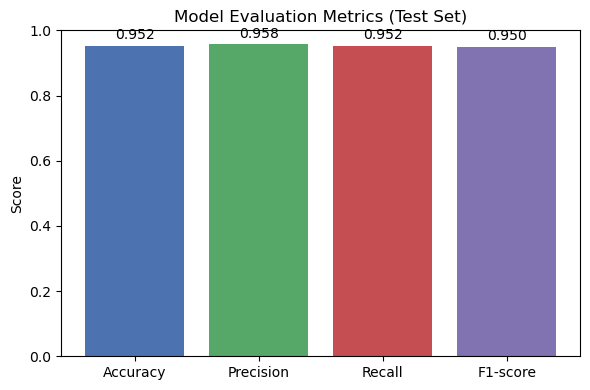

In [32]:
# Step 8B.3: Graph - bar chart of Accuracy, Precision, Recall, F1-score
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
bars = plt.bar(metrics_table['Metric'], metrics_table['Score'],
                color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Evaluation Metrics (Test Set)")
for bar, score in zip(bars, metrics_table['Score']):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 0.02, f"{score:.3f}", ha='center')
plt.tight_layout()
plt.show()

In [33]:
# Step 8B.4: Confusion matrix (table)
from sklearn.metrics import confusion_matrix

intent_labels = sorted(df_chatbot['intent'].unique())
cm = confusion_matrix(y_test, y_pred, labels=intent_labels)
cm_df = pd.DataFrame(cm, index=intent_labels, columns=intent_labels)
cm_df

,Nigeria,Nigerian_business,Nigerian_culture,Nigerian_education,Nigerian_food,Nigerian_geography,Nigerian_history,Nigerian_places,Yoruba_culture,Yoruba_grammar,...,technology,thanks,time,transportation,travel,university,unknown,weather,website,welcome
Nigeria,14,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Nigerian_business,0,13,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Nigerian_culture,0,0,13,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Nigerian_education,0,0,0,13,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Nigerian_food,0,0,0,0,13,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
university,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,13,0,0,0,0
unknown,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,12,0,0,0
weather,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,14,0,0
website,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,13,0


With 150 intents, individual axis labels on the confusion matrix are too
small to read, so the heatmap below omits tick labels and instead shows the
overall pattern — a strong diagonal means most test messages were classified
into their correct intent. The exact counts for every intent pair are in the
`cm_df` table above.

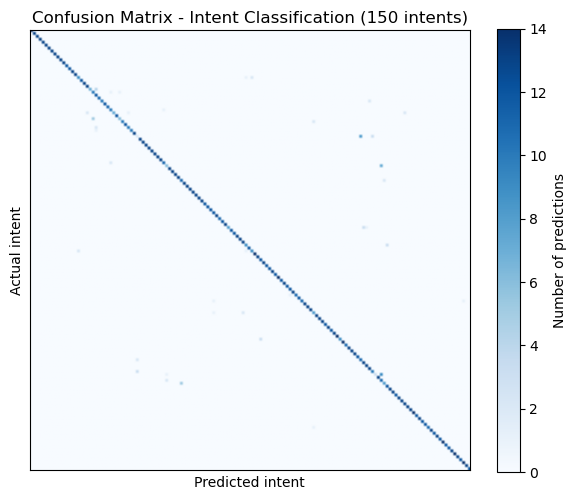

In [34]:
# Step 8B.5: Graph - confusion matrix heatmap
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar(label="Number of predictions")
plt.title("Confusion Matrix - Intent Classification (150 intents)")
plt.xlabel("Predicted intent")
plt.ylabel("Actual intent")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

## Stage 9: Custom User Input

We now define **language identification** (simple, transparent, rule-based — no
extra ML model) and **response selection** (predicted intent + detected language
→ a predefined response), then apply the exact same preprocessing pipeline used
during training to a custom message typed in by the user.

### Language identification

Yoruba-specific diacritics (`ẹ ọ ṣ` and tone marks) or common Yoruba words strongly indicate Yoruba. If the text also contains two or more common English words, we call it Mixed.

In [35]:
# Step 9.1: Rule-based language identification (no ML model)
YORUBA_MARK_CHARS = set("ẹọṣẹ́ẹ̀ọ́ọ̀ṣáàéèíìóòúùńǹ")
YORUBA_COMMON_WORDS = {
    "bawo", "báwo", "pele", "pẹ̀lẹ́", "jare", "jẹ́", "se", "ṣé", "ni", "wa", "wá",
    "mo", "won", "wọn", "nipa", "nípa", "oruko", "orúkọ", "dara", "dáa", "ekaaro",
    "káàárọ̀", "ekaasan", "káàsán", "ekurole", "kúùrọ̀lẹ́", "odabo", "ódàbọ̀", "jowo", "jọ̀ọ́",
}
ENGLISH_COMMON_WORDS = ENGLISH_STOPWORDS | {
    "help", "thanks", "please", "want", "need", "like", "tell", "talk", "hello",
    "hi", "hey", "name", "sorry", "good", "morning", "night", "yes", "no",
}


def contains_yoruba_diacritics(text):
    return any(ch in YORUBA_MARK_CHARS for ch in text.lower())


def detect_language(text):
    has_diacritics = contains_yoruba_diacritics(text)
    words = set(re.findall(r"[a-zà-ǿẹọṣ]+", text.lower()))
    yoruba_hits = len(words & YORUBA_COMMON_WORDS)
    english_hits = len(words & ENGLISH_COMMON_WORDS)

    has_yoruba_signal = has_diacritics or yoruba_hits > 0
    has_english_signal = english_hits >= 2

    if has_yoruba_signal and has_english_signal:
        return "Mixed"
    if has_yoruba_signal:
        return "Yoruba"
    return "English"


for example in ["Hello", "Ẹ káàárọ̀", "Please jọ̀ọ́ help me", "Kí ni orúkọ rẹ?"]:
    print(example, "->", detect_language(example))

Hello -> English
Ẹ káàárọ̀ -> Yoruba
Please jọ̀ọ́ help me -> Mixed
Kí ni orúkọ rẹ? -> Yoruba


### Response selection

A lookup table maps (intent, language) to one of the predefined responses written in Stage 3 — the system never generates a new sentence, it only selects an existing one.

In [36]:
# Step 9.2: Build the (intent, language) -> response lookup table
RESPONSE_LOOKUP = {}
for intent, spec in BESPOKE.items():
    RESPONSE_LOOKUP[(intent, 'English')] = spec['resp_en']
    RESPONSE_LOOKUP[(intent, 'Yoruba')] = spec['resp_yo']
    RESPONSE_LOOKUP[(intent, 'Mixed')] = spec.get('resp_mixed', spec['resp_en'])


def select_response(intent, language):
    return RESPONSE_LOOKUP.get((intent, language), RESPONSE_LOOKUP.get((intent, 'English')))


select_response('greeting', 'Yoruba')

'Ẹ káàárọ̀! Báwo ni mo ṣe lè ràn ẹ́ lọ́wọ́?'

### Preprocessing a custom message

The exact same Stage 5-6 sequence (cleaning, lowercasing, stop-word/frequent/rare-word removal using the sets already fitted on the training data, tokenization, stemming, lemmatization) is applied here — nothing new is fitted on the custom input.

In [37]:
# Step 9.3: Apply the exact same preprocessing pipeline used during training
def preprocess_for_model(text):
    processed = clean_text(text)
    processed = lowercase_text(processed)
    processed = remove_words_text(processed, ALL_STOPWORDS)
    processed = remove_words_text(processed, FREQUENT_WORDS)
    processed = remove_words_text(processed, RARE_WORDS)
    toks = tokenize(processed)
    toks = stem_tokens(toks)
    toks = lemmatize_tokens(toks)
    return ' '.join(toks)


preprocess_for_model("What can you help me with?")

'help'

### Enter a custom message

In [ ]:
#### Step 9.4: Get a message from the user and run the full prediction pipeline
user_message = input("Enter your message (English, Yoruba, or Mixed): ")

processed_message = preprocess_for_model(user_message)
message_tfidf = tfidf.transform([processed_message])
predicted_intent = intent_model.predict(message_tfidf)[0]
detected_language = detect_language(user_message)
chatbot_response = select_response(predicted_intent, detected_language)

## Stage 10: Final Chatbot Response

In [ ]:
# Step 10: Display the final chatbot response
print("User Input:", user_message)
print("Detected Language:", detected_language)
print("Predicted Intent:", predicted_intent)
print("Chatbot Response:", chatbot_response)